In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

# 1. load the file

In [3]:
from pathlib import Path

In [4]:
MANUAL_RAW = Path(
    "/work/Thesis/Data Processing/data/manual_raw.csv"
)

df_manual_raw = pd.read_csv(MANUAL_RAW)

In [5]:
AUTO = Path(
    "/work/Thesis/Data Processing/data/automated_annotations.csv"
)

df_auto_raw = pd.read_csv(AUTO)

/tmp/ipykernel_462/1640999828.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_auto_raw = pd.read_csv(AUTO)


In [6]:
df_manual_raw

,file_name,child_name,uid,label,start_time_s,end_time_s,duration_s
0,Arika_10230,Arika,10230,default,93.270,94.320,1.050
1,Arika_10230,Arika,10230,default,99.090,103.400,4.310
2,Arika_10230,Arika,10230,default,166.920,168.010,1.090
3,Arika_10230,Arika,10230,default,214.315,215.415,1.100
4,Arika_10230,Arika,10230,default,216.090,217.470,1.380
...,...,...,...,...,...,...,...
14376,Tai_10527,Tai,10527,KCH,697.862,698.922,1.060
14377,Tai_10527,Tai,10527,KCH,702.210,702.462,0.252
14378,Tai_10527,Tai,10527,KCH,707.114,708.163,1.049
14379,Tai_10527,Tai,10527,KCH,711.146,712.160,1.014


In [7]:
import pandas as pd

def merge_close_segments_1s_rule(df: pd.DataFrame, gap_threshold: float = 1.0) -> pd.DataFrame:
    """
    Apply the 1-second rule (< 1s) to merge adjacent segments.

    Within the same (file_name, child_name, uid, label), if:
        current_start_time_s - previous_end_time_s < gap_threshold
    then the two segments are merged into one.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
        file_name, child_name, uid, label, start_time_s, end_time_s
    gap_threshold : float
        Merge if gap < gap_threshold. Default is 1.0 (strictly < 1 second).

    Returns
    -------
    pd.DataFrame
        Columns:
        file_name, child_name, uid, label, start_time_s, end_time_s, duration_s
    """
    group_cols = ["file_name", "child_name", "uid", "label"]
    time_cols = ["start_time_s", "end_time_s"]

    # Validate required columns
    required = set(group_cols + time_cols)
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # Sort by group + time so "previous segment" is well-defined
    df_sorted = (
        df.sort_values(group_cols + time_cols)
          .reset_index(drop=True)
          .copy()
    )

    # Previous end time within each group
    prev_end = df_sorted.groupby(group_cols)["end_time_s"].shift(1)

    # Time gap to the previous segment
    gap = df_sorted["start_time_s"] - prev_end

    # Start a new block if:
    # - first row in the group, OR
    # - gap >= threshold (because we ONLY merge when gap < threshold)
    new_block = prev_end.isna() | (gap >= gap_threshold)

    # Create a block id and store it as a real column (avoids pandas FutureWarning)
    df_sorted["_block_id"] = new_block.cumsum()

    # Aggregate each merged block
    out = (
        df_sorted.groupby("_block_id", as_index=False)
                 .agg(
                     file_name=("file_name", "first"),
                     child_name=("child_name", "first"),
                     uid=("uid", "first"),
                     label=("label", "first"),
                     start_time_s=("start_time_s", "min"),
                     end_time_s=("end_time_s", "max"),
                 )
    )

    # Duration in seconds
    out["duration_s"] = out["end_time_s"] - out["start_time_s"]

    # Final ordering
    out = out.sort_values(["file_name", "uid", "start_time_s"]).reset_index(drop=True)

    return out[["file_name", "child_name", "uid", "label",
                "start_time_s", "end_time_s", "duration_s"]]


In [8]:
df_manual_1s = merge_close_segments_1s_rule(df_manual_raw, gap_threshold=1.0)

In [9]:
df_manual_1s 

,file_name,child_name,uid,label,start_time_s,end_time_s,duration_s
0,Arika_10230,Arika,10230,MA1,0.606,1.386,0.780
1,Arika_10230,Arika,10230,KCH,1.866,2.473,0.607
2,Arika_10230,Arika,10230,MA1,2.626,3.926,1.300
3,Arika_10230,Arika,10230,MA1,5.620,6.706,1.086
4,Arika_10230,Arika,10230,KCH,7.093,7.603,0.510
...,...,...,...,...,...,...,...
13494,Tai_10527,Tai,10527,KCH,707.114,708.163,1.049
13495,Tai_10527,Tai,10527,MA1,708.277,710.705,2.428
13496,Tai_10527,Tai,10527,KCH,711.146,712.160,1.014
13497,Tai_10527,Tai,10527,MA1,712.232,713.067,0.835


In [10]:
df_manual_1s["label"].unique()

array(['MA1', 'KCH', 'default', 'FA1'], dtype=object)

In [11]:
label_map = {
    "MA1": "FEM",
    "KCH": "KCHI",
    "default": "DEF",
    "FA1": "MAL"
}

df_manual_1s["label"] = df_manual_1s["label"].replace(label_map)

In [12]:
df_manual_1s

,file_name,child_name,uid,label,start_time_s,end_time_s,duration_s
0,Arika_10230,Arika,10230,FEM,0.606,1.386,0.780
1,Arika_10230,Arika,10230,KCHI,1.866,2.473,0.607
2,Arika_10230,Arika,10230,FEM,2.626,3.926,1.300
3,Arika_10230,Arika,10230,FEM,5.620,6.706,1.086
4,Arika_10230,Arika,10230,KCHI,7.093,7.603,0.510
...,...,...,...,...,...,...,...
13494,Tai_10527,Tai,10527,KCHI,707.114,708.163,1.049
13495,Tai_10527,Tai,10527,FEM,708.277,710.705,2.428
13496,Tai_10527,Tai,10527,KCHI,711.146,712.160,1.014
13497,Tai_10527,Tai,10527,FEM,712.232,713.067,0.835


In [13]:
df_manual_1s[["start_time_s", "end_time_s", "duration_s"]] = \
    df_manual_1s[["start_time_s", "end_time_s", "duration_s"]].round(2)

In [20]:
df_auto_raw

,file_name,child_name,uid,label,start_time_s,end_time_s,duration_s
0,Asato_10127,Asato,10127,FEM,5.22,7.30,2.08
1,Asato_10127,Asato,10127,MAL,7.36,7.96,0.60
2,Asato_10127,Asato,10127,FEM,13.96,15.92,1.96
3,Asato_10127,Asato,10127,MAL,18.48,19.10,0.62
4,Asato_10127,Asato,10127,MAL,20.18,20.30,0.12
...,...,...,...,...,...,...,...
491288,Tai_30129,Tai,30129,KCHI,2730.28,2731.78,1.50
491289,Tai_30129,Tai,30129,KCHI,2731.92,2733.26,1.34
491290,Tai_30129,Tai,30129,KCHI,2736.04,2737.40,1.36
491291,Tai_30129,Tai,30129,KCHI,2740.38,2743.74,3.36


In [21]:
df_auto_1s = merge_close_segments_1s_rule(df_auto_raw, gap_threshold=1.0)

In [22]:
df_auto_1s

,file_name,child_name,uid,label,start_time_s,end_time_s,duration_s
0,Arika_10230,Arika,10230,FEM,0.48,3.98,3.50
1,Arika_10230,Arika,10230,KCHI,1.76,2.58,0.82
2,Arika_10230,Arika,10230,FEM,5.50,6.88,1.38
3,Arika_10230,Arika,10230,KCHI,7.08,7.84,0.76
4,Arika_10230,Arika,10230,KCHI,10.34,11.02,0.68
...,...,...,...,...,...,...,...
372100,Tomito_50123,Tomito,50123,KCHI,4482.04,4482.46,0.42
372101,Tomito_50123,Tomito,50123,KCHI,4485.46,4485.94,0.48
372102,Tomito_50123,Tomito,50123,MAL,4495.88,4497.76,1.88
372103,Tomito_50123,Tomito,50123,KCHI,4498.10,4499.26,1.16


# 2. two dataframes
- manual_1s: df_manual_1s (13499 rows)
- auto_1s: df_auto_1s (372105 rows)

In [134]:
df_manual_1s

,file_name,child_name,uid,label,start_time_s,end_time_s,duration_s
0,Arika_10230,Arika,10230,FEM,0.61,1.39,0.78
1,Arika_10230,Arika,10230,KCHI,1.87,2.47,0.61
2,Arika_10230,Arika,10230,FEM,2.63,3.93,1.30
3,Arika_10230,Arika,10230,FEM,5.62,6.71,1.09
4,Arika_10230,Arika,10230,KCHI,7.09,7.60,0.51
...,...,...,...,...,...,...,...
13494,Tai_10527,Tai,10527,KCHI,707.11,708.16,1.05
13495,Tai_10527,Tai,10527,FEM,708.28,710.70,2.43
13496,Tai_10527,Tai,10527,KCHI,711.15,712.16,1.01
13497,Tai_10527,Tai,10527,FEM,712.23,713.07,0.84


In [135]:
manual_files = df_manual_1s["file_name"].dropna().unique().tolist()

print("Number of unique manual files:", len(manual_files))
print(manual_files)

Number of unique manual files: 17
['Arika_10230', 'Arika_20001', 'Arika_30002', 'Asato_10319', 'Asato_20008', 'Asato_30019', 'Jun_10000', 'Jun_10008', 'Jun_10011', 'Jun_20002', 'Jun_21021', 'Jun_30001', 'Nanami_10129', 'Nanami_10225', 'Nanami_20200', 'Nanami_30220', 'Tai_10527']


In [ ]:
#span = min(start_time_s) ~ max(end_time_s)

In [136]:
df_manual_span = (
    df_manual_1s
    .groupby("file_name", as_index=False)
    .agg(
        manual_start_min=("start_time_s", "min"),
        manual_end_max=("end_time_s", "max")
    )
)

df_manual_span
# print("Number of manual spans:", len(df_manual_span))


,file_name,manual_start_min,manual_end_max
0,Arika_10230,0.61,4318.27
1,Arika_20001,0.75,3749.84
2,Arika_30002,0.56,3015.60
3,Asato_10319,93.65,3498.89
4,Asato_20008,85.80,3690.33
5,Asato_30019,354.82,4301.39
6,Jun_10000,0.08,892.47
7,Jun_10008,2.20,897.42
8,Jun_10011,2.71,898.70
9,Jun_20002,0.36,1286.51


In [137]:
df_auto_1s_overlap = df_auto_1s[df_auto_1s["file_name"].isin(manual_files)].copy()
df_auto_1s_non = df_auto_1s[~df_auto_1s["file_name"].isin(manual_files)].copy()

print("df_auto_1s_overlap shape:", df_auto_1s_overlap.shape)
print("df_auto_1s_non shape:", df_auto_1s_non.shape)


df_auto_1s_overlap shape: (13584, 7)
df_auto_1s_non shape: (358521, 7)


In [138]:
13584 + 358521

372105

In [139]:
df_auto_1s_overlap = df_auto_1s_overlap.merge(
    df_manual_span,
    on="file_name",
    how="left"
)

print(df_auto_1s_overlap.head())


     file_name child_name    uid label  start_time_s  end_time_s  duration_s  \
0  Arika_10230      Arika  10230   FEM          0.48        3.98        3.50   
1  Arika_10230      Arika  10230  KCHI          1.76        2.58        0.82   
2  Arika_10230      Arika  10230   FEM          5.50        6.88        1.38   
3  Arika_10230      Arika  10230  KCHI          7.08        7.84        0.76   
4  Arika_10230      Arika  10230  KCHI         10.34       11.02        0.68   

   manual_start_min  manual_end_max  
0              0.61         4318.27  
1              0.61         4318.27  
2              0.61         4318.27  
3              0.61         4318.27  
4              0.61         4318.27  


In [ ]:
#   end_time_s >= manual_start_min
#   start_time_s <= manual_end_max

In [140]:
mask_overlap_span = (
    (df_auto_1s_overlap["end_time_s"] >= df_auto_1s_overlap["manual_start_min"]) &
    (df_auto_1s_overlap["start_time_s"] <= df_auto_1s_overlap["manual_end_max"])
)

df_auto_1s_overlap_trimmed = df_auto_1s_overlap[mask_overlap_span].copy()

print("Original overlap shape:", df_auto_1s_overlap.shape)
print("Trimmed overlap shape:", df_auto_1s_overlap_trimmed.shape)

Original overlap shape: (13584, 9)
Trimmed overlap shape: (11270, 9)


In [141]:
len(df_manual_1s)

13499

In [142]:
df_auto_1s_overlap_trimmed = df_auto_1s_overlap_trimmed.drop(
    columns=["manual_start_min", "manual_end_max"]
)

print(df_auto_1s_overlap_trimmed.head())

     file_name child_name    uid label  start_time_s  end_time_s  duration_s
0  Arika_10230      Arika  10230   FEM          0.48        3.98        3.50
1  Arika_10230      Arika  10230  KCHI          1.76        2.58        0.82
2  Arika_10230      Arika  10230   FEM          5.50        6.88        1.38
3  Arika_10230      Arika  10230  KCHI          7.08        7.84        0.76
4  Arika_10230      Arika  10230  KCHI         10.34       11.02        0.68


In [143]:
len(df_auto_1s_overlap_trimmed)

11270

In [144]:
df_auto_1s_final = pd.concat(
    [df_auto_1s_non, df_auto_1s_overlap_trimmed],
    ignore_index=True
)

print("Final auto shape:", df_auto_1s_final.shape)

Final auto shape: (369791, 7)


In [47]:
pd.crosstab(
    df_manual_1s["label"],
    columns="manual"
)

col_0,manual
label,
DEF,76
FEM,5989
KCHI,5763
MAL,1671


In [48]:
pd.crosstab(
    df_auto_1s_overlap_trimmed["label"],
    columns="auto"
)

col_0,auto
label,
FEM,3766
KCHI,5464
MAL,1650
OCH,390


In [51]:
len(df_auto_1s_final)

369791

In [52]:
len(df_manual_1s)

13499

- df_manual_1s (13499)
- df_auto_1s_final (369791)

# 3. Compute RL

Compute response latency based on floor holding and response onset.

Rules
-----
1. Process each file separately.
2. Sort within each file by start time, then end time.
3. For a current floor holder A, if another speaker B starts speaking at any point during A's floor episode, record one A -> B response event, regardless of whether B successfully takes the floor.
4. Response latency is defined as:
           B_attempt_start - A_floor_end,
       so it may be negative, zero, or positive.
5. Multiple overlapping or fragmented segments from the same speaker B during A's floor episode are merged into one attempt.
6. A speaker B is considered to have successfully taken the floor only if:
           B_attempt_end > A_floor_end
7. Only a successful floor transfer can create the next directional relation
       (e.g. B -> A later).

In [145]:
def compute_response_latency(
    df: pd.DataFrame,
    file_col: str = "file_name",
    speaker_col: str = "label",
    start_col: str = "start_time_s",
    end_col: str = "end_time_s",
) -> pd.DataFrame:
    """
    Returns
    -------
    pd.DataFrame
        One row per response event, with columns:
        file_name, from, to, response_latency_s,
        floor_holder_start_s, floor_holder_end_s,
        new_turn_start_s, new_turn_end_s,
        successful_transfer
    """
    required_cols = {file_col, speaker_col, start_col, end_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    data = df.copy()

    # Remove rows with missing values
    data = data.dropna(subset=[file_col, speaker_col, start_col, end_col]).copy()

    # Keep only valid intervals
    data = data[data[end_col] >= data[start_col]].copy()

    # Stable ordering within each file
    data = data.sort_values(
        by=[file_col, start_col, end_col],
        ascending=[True, True, True]
    ).reset_index(drop=True)

    results = []

    for file_name, seg_df in data.groupby(file_col, sort=False):
        seg_df = seg_df.reset_index(drop=True)

        if seg_df.empty:
            continue

        # Initialize the first floor holder
        current_floor_speaker = seg_df.loc[0, speaker_col]
        current_floor_start = seg_df.loc[0, start_col]
        current_floor_end = seg_df.loc[0, end_col]

        # Store attempts from other speakers during the current floor episode
        # Format:
        # attempts[speaker] = {
        #     "start": first onset within current floor,
        #     "end": max offset across all fragments in current floor
        # }
        attempts = {}

        def finalize_current_floor(
            file_name,
            floor_speaker,
            floor_start,
            floor_end,
            attempts_dict,
            winner_speaker=None
        ):
            """
            Write all response events collected during the current floor episode.
            """
            rows = []
            for spk, attempt in attempts_dict.items():
                rows.append({
                    file_col: file_name,
                    "from": floor_speaker,
                    "to": spk,
                    "response_latency_s": attempt["start"] - floor_end,
                    "floor_holder_start_s": floor_start,
                    "floor_holder_end_s": floor_end,
                    "new_turn_start_s": attempt["start"],
                    "new_turn_end_s": attempt["end"],
                    "successful_transfer": spk == winner_speaker,
                })
            return rows

        for i in range(1, len(seg_df)):
            row = seg_df.loc[i]
            speaker = row[speaker_col]
            start = row[start_col]
            end = row[end_col]

            # Same speaker as current floor holder: extend the current floor
            if speaker == current_floor_speaker:
                if end > current_floor_end:
                    current_floor_end = end
                continue

            # Different speaker: create or update one merged attempt
            if speaker not in attempts:
                attempts[speaker] = {"start": start, "end": end}
            else:
                attempts[speaker]["end"] = max(attempts[speaker]["end"], end)

            # Check whether any competing speaker has outlasted the current floor holder
            eligible = {
                spk: att for spk, att in attempts.items()
                if att["end"] > current_floor_end
            }

            if eligible:
                # Choose the speaker with the latest end as the new floor holder
                winner_speaker = max(
                    eligible,
                    key=lambda spk: (eligible[spk]["end"], -eligible[spk]["start"])
                )
                winner_attempt = eligible[winner_speaker]

                # Finalize all A -> X events for the current floor episode
                results.extend(
                    finalize_current_floor(
                        file_name=file_name,
                        floor_speaker=current_floor_speaker,
                        floor_start=current_floor_start,
                        floor_end=current_floor_end,
                        attempts_dict=attempts,
                        winner_speaker=winner_speaker
                    )
                )

                # Promote winner to the new floor holder
                current_floor_speaker = winner_speaker
                current_floor_start = winner_attempt["start"]
                current_floor_end = winner_attempt["end"]

                # Reset attempts for the new floor episode
                attempts = {}

        # Finalize any remaining unsuccessful attempts at the end of the file
        if attempts:
            results.extend(
                finalize_current_floor(
                    file_name=file_name,
                    floor_speaker=current_floor_speaker,
                    floor_start=current_floor_start,
                    floor_end=current_floor_end,
                    attempts_dict=attempts,
                    winner_speaker=None
                )
            )

    return pd.DataFrame(results)

In [146]:
RL_manual = compute_response_latency(df_manual_1s)

In [147]:
(RL_manual["successful_transfer"] == False).sum()

np.int64(17)

In [148]:
RL_auto = compute_response_latency(df_auto_1s_final)

In [149]:
(RL_auto["successful_transfer"] == False).sum()

np.int64(3198)

In [150]:
len(RL_auto) 

229026

In [151]:
len(RL_manual)

8608

In [153]:
import re
import numpy as np

def extract_child_age(df):

    # child name
    df["child_name"] = df["file_name"].str.split("_").str[0]

    # age
    df["age"] = df["file_name"].apply(
        lambda x: round(int(re.search(r'_(\d+)', x).group(1)) / 100)
        if re.search(r'_(\d+)', x) else np.nan
    )

    return df


RL_auto = extract_child_age(RL_auto)
RL_manual = extract_child_age(RL_manual)

In [156]:
key_children_fem = {"Arika", "Nanami", "Asato", "Tai", "Tomito"}
key_children_mal = {"Jun"}

def filter_key_speaker_turns(df):
    # Condition 1:
    # child_name in {Arika, Nanami, Asato, Tai, Tomito}
    # keep only FEM <-> KCHI
    cond_fem = (
        df["child_name"].isin(key_children_fem)
        & (
            ((df["from"] == "FEM") & (df["to"] == "KCHI"))
            | ((df["from"] == "KCHI") & (df["to"] == "FEM"))
        )
    )

    # Condition 2:
    # child_name == Jun
    # keep only MAL <-> KCHI
    cond_mal = (
        df["child_name"].isin(key_children_mal)
        & (
            ((df["from"] == "MAL") & (df["to"] == "KCHI"))
            | ((df["from"] == "KCHI") & (df["to"] == "MAL"))
        )
    )

    return df[cond_fem | cond_mal].copy()


RL_auto_key = filter_key_speaker_turns(RL_auto)
RL_manual_key = filter_key_speaker_turns(RL_manual)

In [159]:
RL_manual_key

,file_name,from,to,response_latency_s,floor_holder_start_s,floor_holder_end_s,new_turn_start_s,new_turn_end_s,successful_transfer,child_name,age
0,Arika_10230,FEM,KCHI,0.48,0.61,1.39,1.87,2.47,True,Arika,102
1,Arika_10230,KCHI,FEM,0.16,1.87,2.47,2.63,3.93,True,Arika,102
2,Arika_10230,FEM,KCHI,0.38,2.63,6.71,7.09,7.60,True,Arika,102
3,Arika_10230,KCHI,FEM,0.43,7.09,7.60,8.03,10.11,True,Arika,102
4,Arika_10230,FEM,KCHI,0.19,8.03,10.11,10.30,10.80,True,Arika,102
...,...,...,...,...,...,...,...,...,...,...,...
8603,Tai_10527,FEM,KCHI,1.24,703.42,705.87,707.11,708.16,True,Tai,105
8604,Tai_10527,KCHI,FEM,0.12,707.11,708.16,708.28,710.70,True,Tai,105
8605,Tai_10527,FEM,KCHI,0.45,708.28,710.70,711.15,712.16,True,Tai,105
8606,Tai_10527,KCHI,FEM,0.07,711.15,712.16,712.23,713.07,True,Tai,105


In [160]:
RL_auto_key

,file_name,from,to,response_latency_s,floor_holder_start_s,floor_holder_end_s,new_turn_start_s,new_turn_end_s,successful_transfer,child_name,age
0,Arika_10230,FEM,KCHI,-5.12,0.48,6.88,1.76,7.84,True,Arika,102
1,Arika_10230,KCHI,FEM,0.18,1.76,11.02,11.20,13.76,True,Arika,102
2,Arika_10230,FEM,KCHI,-0.02,11.20,13.76,13.74,15.22,True,Arika,102
3,Arika_10230,KCHI,FEM,0.02,13.74,15.22,15.24,16.60,True,Arika,102
4,Arika_10230,FEM,KCHI,-0.06,15.24,16.60,16.54,18.04,True,Arika,102
...,...,...,...,...,...,...,...,...,...,...,...
229006,Tomito_50123,KCHI,FEM,12.58,4120.14,4179.00,4191.58,4194.92,True,Tomito,501
229007,Tomito_50123,FEM,KCHI,7.26,4191.58,4251.34,4258.60,4262.38,True,Tomito,501
229008,Tomito_50123,KCHI,FEM,-21.50,4258.60,4295.92,4274.42,4296.70,True,Tomito,501
229009,Tomito_50123,FEM,KCHI,0.54,4274.42,4296.70,4297.24,4299.12,True,Tomito,501


In [161]:
import numpy as np

def add_previous_latency_metrics(df):
    df = df.copy()

    # Ensure columns exist
    df["inter_pre_lat"] = np.nan
    df["self_pre_lat"] = np.nan

    # Process each file_name group separately
    for file_name, group in df.groupby("file_name", sort=False):
        idx = group.index.tolist()  # keep original row indices

        for i in range(1, len(group)):
            curr = group.iloc[i]
            prev = group.iloc[i - 1]

            # ① inter_pre_lat
            # If current 'to' is different from previous 'to',
            # assign the previous response latency
            if curr["to"] != prev["to"]:
                df.loc[idx[i], "inter_pre_lat"] = prev["response_latency_s"]
            else:
                df.loc[idx[i], "inter_pre_lat"] = np.nan

            # ② self_pre_lat
            # Look back for the last row with the same 'to'
            same_dir = group.iloc[:i][group.iloc[:i]["to"] == curr["to"]]

            if len(same_dir) > 0:
                df.loc[idx[i], "self_pre_lat"] = same_dir.iloc[-1]["response_latency_s"]
            else:
                df.loc[idx[i], "self_pre_lat"] = np.nan

    return df

In [162]:
RL_auto_key = add_previous_latency_metrics(RL_auto_key)
RL_manual_key = add_previous_latency_metrics(RL_manual_key)

In [163]:
RL_manual_key 

,file_name,from,to,response_latency_s,floor_holder_start_s,floor_holder_end_s,new_turn_start_s,new_turn_end_s,successful_transfer,child_name,age,inter_pre_lat,self_pre_lat
0,Arika_10230,FEM,KCHI,0.48,0.61,1.39,1.87,2.47,True,Arika,102,NaN,NaN
1,Arika_10230,KCHI,FEM,0.16,1.87,2.47,2.63,3.93,True,Arika,102,0.48,NaN
2,Arika_10230,FEM,KCHI,0.38,2.63,6.71,7.09,7.60,True,Arika,102,0.16,0.48
3,Arika_10230,KCHI,FEM,0.43,7.09,7.60,8.03,10.11,True,Arika,102,0.38,0.16
4,Arika_10230,FEM,KCHI,0.19,8.03,10.11,10.30,10.80,True,Arika,102,0.43,0.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8603,Tai_10527,FEM,KCHI,1.24,703.42,705.87,707.11,708.16,True,Tai,105,0.96,-0.09
8604,Tai_10527,KCHI,FEM,0.12,707.11,708.16,708.28,710.70,True,Tai,105,1.24,0.96
8605,Tai_10527,FEM,KCHI,0.45,708.28,710.70,711.15,712.16,True,Tai,105,0.12,1.24
8606,Tai_10527,KCHI,FEM,0.07,711.15,712.16,712.23,713.07,True,Tai,105,0.45,0.12


In [164]:
RL_auto_key

,file_name,from,to,response_latency_s,floor_holder_start_s,floor_holder_end_s,new_turn_start_s,new_turn_end_s,successful_transfer,child_name,age,inter_pre_lat,self_pre_lat
0,Arika_10230,FEM,KCHI,-5.12,0.48,6.88,1.76,7.84,True,Arika,102,NaN,NaN
1,Arika_10230,KCHI,FEM,0.18,1.76,11.02,11.20,13.76,True,Arika,102,-5.12,NaN
2,Arika_10230,FEM,KCHI,-0.02,11.20,13.76,13.74,15.22,True,Arika,102,0.18,-5.12
3,Arika_10230,KCHI,FEM,0.02,13.74,15.22,15.24,16.60,True,Arika,102,-0.02,0.18
4,Arika_10230,FEM,KCHI,-0.06,15.24,16.60,16.54,18.04,True,Arika,102,0.02,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229006,Tomito_50123,KCHI,FEM,12.58,4120.14,4179.00,4191.58,4194.92,True,Tomito,501,0.76,1.52
229007,Tomito_50123,FEM,KCHI,7.26,4191.58,4251.34,4258.60,4262.38,True,Tomito,501,12.58,0.76
229008,Tomito_50123,KCHI,FEM,-21.50,4258.60,4295.92,4274.42,4296.70,True,Tomito,501,7.26,12.58
229009,Tomito_50123,FEM,KCHI,0.54,4274.42,4296.70,4297.24,4299.12,True,Tomito,501,-21.50,7.26


In [165]:
RL_auto_key["year"] = RL_auto_key["age"] // 100
RL_manual_key["year"] = RL_manual_key["age"] // 100

In [167]:
RL_manual_key["Annotator"] = "manual"

In [168]:
RL_auto_key["Annotator"] = "vtc2"

In [170]:
# Rename columns
RL_auto_key = RL_auto_key.rename(columns={
    "file_name": "File",
    "child_name": "Child",
    "age": "Age_month",
    "to": "Speaker",
    "response_latency_s": "RL_s",
    "year": "Year",
    "inter_pre_lat": "PrevInterLatency",
    "self_pre_lat": "PrevSelfLatency"
})

# Reorder columns
RL_auto_key = RL_auto_key[
    [
        "File",
        "Annotator",
        "Child",
        "Age_month",
        "from",
        "Speaker",
        "RL_s",
        "Year",
        "PrevInterLatency",
        "PrevSelfLatency"
    ]
]

In [171]:
RL_auto_key

,File,Annotator,Child,Age_month,from,Speaker,RL_s,Year,PrevInterLatency,PrevSelfLatency
0,Arika_10230,vtc2,Arika,102,FEM,KCHI,-5.12,1,NaN,NaN
1,Arika_10230,vtc2,Arika,102,KCHI,FEM,0.18,1,-5.12,NaN
2,Arika_10230,vtc2,Arika,102,FEM,KCHI,-0.02,1,0.18,-5.12
3,Arika_10230,vtc2,Arika,102,KCHI,FEM,0.02,1,-0.02,0.18
4,Arika_10230,vtc2,Arika,102,FEM,KCHI,-0.06,1,0.02,-0.02
...,...,...,...,...,...,...,...,...,...,...
229006,Tomito_50123,vtc2,Tomito,501,KCHI,FEM,12.58,5,0.76,1.52
229007,Tomito_50123,vtc2,Tomito,501,FEM,KCHI,7.26,5,12.58,0.76
229008,Tomito_50123,vtc2,Tomito,501,KCHI,FEM,-21.50,5,7.26,12.58
229009,Tomito_50123,vtc2,Tomito,501,FEM,KCHI,0.54,5,-21.50,7.26


In [172]:
# Rename columns
RL_manual_key = RL_manual_key.rename(columns={
    "file_name": "File",
    "child_name": "Child",
    "age": "Age_month",
    "to": "Speaker",
    "response_latency_s": "RL_s",
    "year": "Year",
    "inter_pre_lat": "PrevInterLatency",
    "self_pre_lat": "PrevSelfLatency"
})

# Reorder columns
RL_manual_key = RL_manual_key[
    [
        "File",
        "Annotator",
        "Child",
        "Age_month",
        "from",
        "Speaker",
        "RL_s",
        "Year",
        "PrevInterLatency",
        "PrevSelfLatency"
    ]
]

In [174]:
RL_manual_key

,File,Annotator,Child,Age_month,from,Speaker,RL_s,Year,PrevInterLatency,PrevSelfLatency
0,Arika_10230,manual,Arika,102,FEM,KCHI,0.48,1,NaN,NaN
1,Arika_10230,manual,Arika,102,KCHI,FEM,0.16,1,0.48,NaN
2,Arika_10230,manual,Arika,102,FEM,KCHI,0.38,1,0.16,0.48
3,Arika_10230,manual,Arika,102,KCHI,FEM,0.43,1,0.38,0.16
4,Arika_10230,manual,Arika,102,FEM,KCHI,0.19,1,0.43,0.38
...,...,...,...,...,...,...,...,...,...,...
8603,Tai_10527,manual,Tai,105,FEM,KCHI,1.24,1,0.96,-0.09
8604,Tai_10527,manual,Tai,105,KCHI,FEM,0.12,1,1.24,0.96
8605,Tai_10527,manual,Tai,105,FEM,KCHI,0.45,1,0.12,1.24
8606,Tai_10527,manual,Tai,105,KCHI,FEM,0.07,1,0.45,0.12


In [175]:
df_all = pd.concat([RL_manual_key, RL_auto_key], ignore_index=True)

In [176]:
df_all

,File,Annotator,Child,Age_month,from,Speaker,RL_s,Year,PrevInterLatency,PrevSelfLatency
0,Arika_10230,manual,Arika,102,FEM,KCHI,0.48,1,NaN,NaN
1,Arika_10230,manual,Arika,102,KCHI,FEM,0.16,1,0.48,NaN
2,Arika_10230,manual,Arika,102,FEM,KCHI,0.38,1,0.16,0.48
3,Arika_10230,manual,Arika,102,KCHI,FEM,0.43,1,0.38,0.16
4,Arika_10230,manual,Arika,102,FEM,KCHI,0.19,1,0.43,0.38
...,...,...,...,...,...,...,...,...,...,...
190433,Tomito_50123,vtc2,Tomito,501,KCHI,FEM,12.58,5,0.76,1.52
190434,Tomito_50123,vtc2,Tomito,501,FEM,KCHI,7.26,5,12.58,0.76
190435,Tomito_50123,vtc2,Tomito,501,KCHI,FEM,-21.50,5,7.26,12.58
190436,Tomito_50123,vtc2,Tomito,501,FEM,KCHI,0.54,5,-21.50,7.26


In [ ]:
# df_all.to_csv("/work/Thesis/Data Processing/data/RL_all_annotations.csv", index=False)

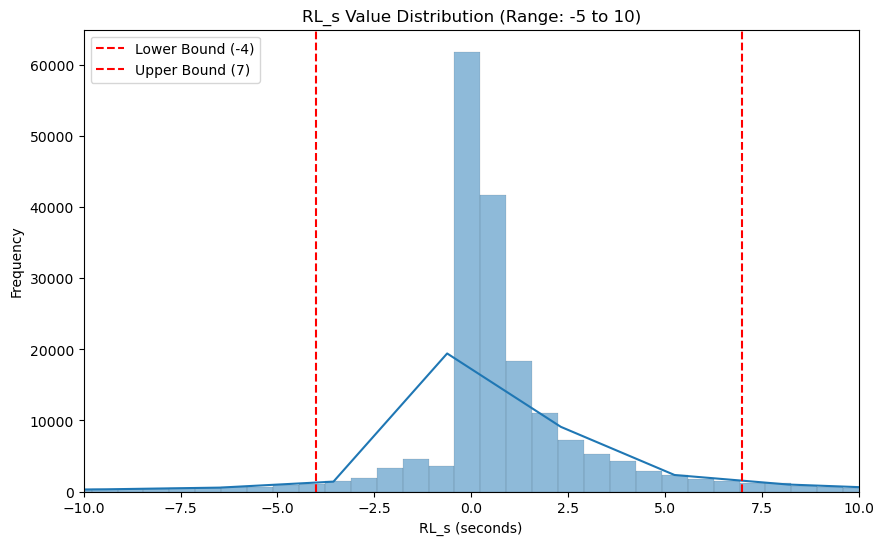

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.histplot(df_all['RL_s'], kde=True)

plt.axvline(-4, color='red', linestyle='--', label='Lower Bound (-4)')
plt.axvline(7, color='red', linestyle='--', label='Upper Bound (7)')


plt.xlim(-10, 10)
plt.title('RL_s Value Distribution (Range: -5 to 10)')
plt.xlabel('RL_s (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.show()